# Lab 3 — KNN, Naive Bayes and Decision Trees

**T-504-ITML — Machine Learning, Fall 2026**

Names: Dagur Smari (dagurss24@ru.is) & Kamil Michal (kamil24@ru.is)

---
## The setup

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

---
## Task 1 - Loading and exploring the data

In [2]:
from sklearn.datasets import fetch_20newsgroups
newsgroups = fetch_20newsgroups(subset='all')

### 1.a How many instances (examples) and variables are in the dataset?

In [3]:
print("instances:", len(newsgroups.data))
print("type of one instance:", type(newsgroups.data[0]))

instances: 18846
type of one instance: <class 'str'>


There are 18,846 instances in the set and one variable, the text.

### 1.b How many and which classes does the dataset define? What is their share in the data?

In [4]:
class_names = newsgroups.target_names
print("Number of classes:", len(class_names))

counts = pd.Series(newsgroups.target).value_counts().sort_index()
dist = pd.DataFrame({
    "class": class_names,
    "count": counts.values,
    "share_%": (counts.values / counts.sum() * 100).round(2),
})
dist

Number of classes: 20


,class,count,share_%
0,alt.atheism,799,4.24
1,comp.graphics,973,5.16
2,comp.os.ms-windows.misc,985,5.23
3,comp.sys.ibm.pc.hardware,982,5.21
4,comp.sys.mac.hardware,963,5.11
5,comp.windows.x,988,5.24
6,misc.forsale,975,5.17
7,rec.autos,990,5.25
8,rec.motorcycles,996,5.28
9,rec.sport.baseball,994,5.27


The dataset defines 20 classes, one per newsgroup. They are near-balanced: each holds roughly 5% of the data. The smallest is `talk.religion.misc` at 628 posts and the largest `rec.sport.hockey` at 999, a ratio of about 1.6.


### 1.c Make a plot showing the class distribution in the dataset.

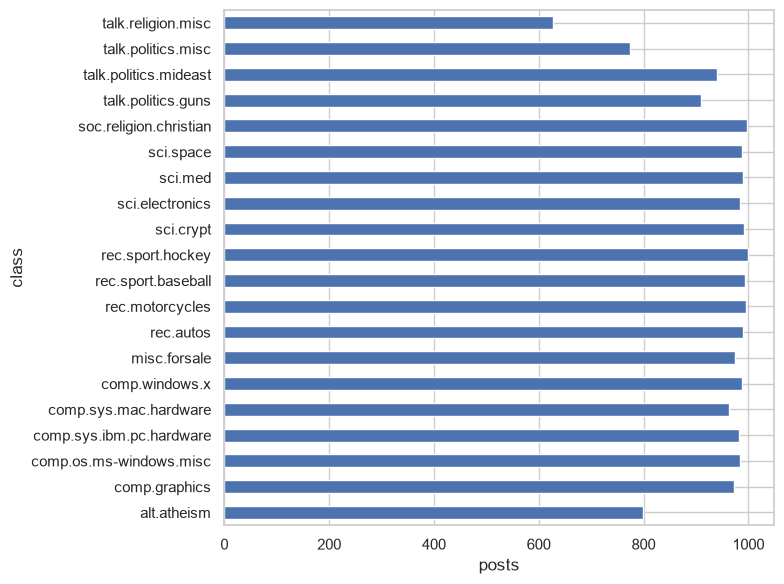

In [5]:
#dist is the data frame built in 1b
dist.plot.barh(x="class", y="count", legend=False, figsize=(8, 6))
plt.xlabel("posts")
plt.tight_layout()
plt.show()

### 1.d Is there anything in the examples that might cause a classifier to overfit? How can you fix this?

In [6]:
# Look at three raw samples in full, not just the first 400 characters.
for i in [0, 5000, 12000]:
    print("CLASS:", newsgroups.target_names[newsgroups.target[i]])
    print(newsgroups.data[i])
    print("=" * 60)

CLASS: rec.sport.hockey
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


CLASS: misc.forsale
From: nave@jato.jpl.nasa.gov (Joe Nave)
Subject: C=64

**What's in the samples.** Headers contain the `Newsgroups:` line (the label itself), plus `Organization:` and sender domain. Footers are author signature blocks. Quotes are `>` lines duplicating other posts in the thread.

**Why it overfits.** The classifier learns author and organisation identity, not topic. And since headers are in the test set too, a normal split won't expose it. The inflated score looks fine.

**Fix.** `remove=('headers', 'footers', 'quotes')`. Docs note `'headers'` follows an exact standard, the other two are heuristic and not always correct.

Accuracy drops after this. That's the honest number.

In [7]:
# The fix
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
)
X = newsgroups.data
y = newsgroups.target
class_names = newsgroups.target_names

---
## Task 2 - Splitting into training and test data

### 2.a Split into training and test set, 20% for testing, preserving class distributions.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("train:", len(X_train))
print("test:", len(X_test))

train: 15076
test: 3770


short explination

### 2.b Plot to check the test set distribution matches the whole dataset.

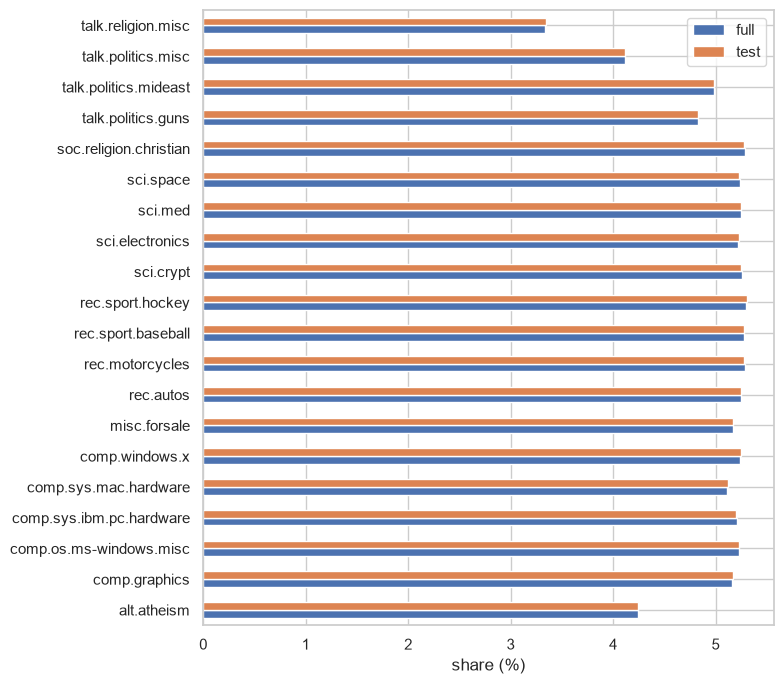

max deviation (pp): 0.0117


In [9]:
w = pd.DataFrame({
    "full": pd.Series(y).value_counts(normalize=True).sort_index().values * 100,
    "test": pd.Series(y_test).value_counts(normalize=True).sort_index().values * 100,
}, index=class_names)

w.plot.barh(figsize=(8, 7))
plt.xlabel("share (%)")
plt.tight_layout()
plt.show()

print("max deviation (pp): %.4f" % (w["test"] - w["full"]).abs().max())

short explination

---
## Task 3 - Feature engineering / extraction

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)

### 3.a How many attributes do we get? Is this a good number? Why (not)?

In [11]:
print("shape:", X_train_counts.shape)
print("attributes:", X_train_counts.shape[1])

shape: (15076, 123548)
attributes: 123548


123,548 attributes, one per distinct token in the training set.

Not a good number. That's eight times more attributes than the 15,076 training documents, so a model can separate the training data without learning anything that generalises. Much of the vocabulary appears in only one or two documents (typos, hostnames, numbers) and can never help on unseen text. It hurts KNN most: every attribute enters the distance with equal weight, so irrelevant ones can't be ignored, and in this many dimensions distances stop being informative.

### 3.b Exclude words in more than half the instances and in fewer than 0.1% of instances. How many attributes now?

In [12]:
vectorizer = CountVectorizer(max_df=0.5, min_df=0.001)
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print("attributes:", X_train_counts.shape[1])
print("0.1% of", len(X_train), "docs =", 0.001 * len(X_train))

attributes: 9123
0.1% of 15076 docs = 15.076


9,123 attributes, down from 123,548. Both thresholds are floats, so sklearn reads them as proportions: min_df=0.001 means a term must appear in at least 15 of the 15,076 documents. max_df=0.5 drops terms in more than half the documents, a data-driven stop-word filter that removes few terms but the most frequent ones. min_df is where nearly all the reduction comes from

### 3.c Apply a TfidfTransformer to the output of the CountVectorizer.

In [13]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

print("train:", X_train_tfidf.shape)
print("test:", X_test_tfidf.shape)

train: (15076, 9123)
test: (3770, 9123)


Each count is multiplied by idf, which is high for terms appearing in few documents and low for common ones, so raw frequency no longer means a high weight. Rows are then L2-normalised, so long and short posts on the same topic end up comparable rather than the long one looking distant. Fitted on training data only, since idf is a corpus statistic.

---
## Task 4 - raining a model and evaluating with cross-validation

**4a**

In [14]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier()
neigh.fit(X_train_tfidf,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](20,)","[ 0, 1, 2,...,17,18,19]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


**4b**

5, the function defaultly uses 5. Also if we click on Parameters (The class returned), we see n_neighbors = 5

**4c**

In [15]:
from sklearn.model_selection import cross_validate
results = cross_validate(neigh, X_train_tfidf, y_train, cv=5, scoring="accuracy", return_train_score=True)

print("Training accuracy: ",results["train_score"])
print("Validation accuracy: ",results["test_score"])


Training accuracy:  [0.37147595 0.36804577 0.36978692 0.36812868 0.37119642]
Validation accuracy:  [0.10444297 0.10646766 0.10580431 0.12338308 0.10182421]


**4d**

These numbers point to overfitting, because we can see that the validation accuracy is much lower than the training accuracy. This means the model is performing okay on training data, but badly on data he hasn't seen. 

**4e**

In [16]:
from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

results = cross_validate(clf, X_train_tfidf, y_train, cv=5, scoring="accuracy", return_train_score=True)

print("Training accuracy: ",results["train_score"])
print("Validation accuracy: ",results["test_score"])


Training accuracy:  [0.80696517 0.80308432 0.80233811 0.8022552  0.80333306]
Validation accuracy:  [0.69628647 0.67595357 0.68855721 0.67794362 0.70016584]


Seems to be working much better, now we don't see such a big overfitting, however there is still some. We see on avg a 10% difference, but that is much lower than the avg 26% with the knn. 

**5a**

In [17]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([("vectorizer", CountVectorizer()),("tfidf", TfidfTransformer()), ("multinomialnb", MultinomialNB())])


**5b**

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    "vectorizer__min_df": [0.001, 0.01, 0.005],
    "vectorizer__max_df": [0.5, 0.8, 0.3],
    "tfidf__sublinear_tf": [False, True],
    "multinomialnb__alpha": [1.0, 0.1, 10.0],
    "multinomialnb__fit_prior": [True,False]
}

grid = GridSearchCV(pipeline, params, cv=5, scoring="accuracy", return_train_score=True, n_jobs=-1)

grid.fit(X_train, y_train)
print("Best parameters: ", grid.best_params_)
print("Score: ", grid.best_score_)

Best parameters:  {'multinomialnb__alpha': 0.1, 'multinomialnb__fit_prior': False, 'tfidf__sublinear_tf': False, 'vectorizer__max_df': 0.8, 'vectorizer__min_df': 0.001}
Score:  0.7182273864981019


In [19]:
bestindex = grid.best_index_

print("Training accuracy: ", f"{grid.cv_results_["mean_train_score"][bestindex]:.3f}")
print("Validation accuracy: ", f"{grid.cv_results_["mean_test_score"][bestindex]:.3f}")

Training accuracy:  0.890
Validation accuracy:  0.718


**5c**

So the best parameters are:

{'multinomialnb__alpha': 0.1, 
'multinomialnb__fit_prior': False, 
'tfidf__sublinear_tf': False, 
'vectorizer__max_df': 0.8, 
'vectorizer__min_df': 0.001}

This is better then we had before, we are around 1-2% higher in the validation and around 9% higher in training accuracy. However the overfitting is higher than in the previous model. Now we have around 17.2% overfitting, but before we had around 10%. So model performs better on validation, but is also overfitting more. 


**5d**

Firstly, we are going to add a gap to the data to see the difference between train and test data for each parameter. 

In [20]:
data = pd.DataFrame(grid.cv_results_)

parameters = [
    "param_vectorizer__min_df",
    "param_vectorizer__max_df",
    "param_tfidf__sublinear_tf",
    "param_multinomialnb__alpha",
    "param_multinomialnb__fit_prior"
]

data["gap"] = (data["mean_train_score"] - data["mean_test_score"])

for par in parameters:
    print(data.groupby(par)[["mean_train_score", "mean_test_score", "gap"]].mean())

                          mean_train_score  mean_test_score       gap
param_vectorizer__min_df                                             
0.001                             0.787014         0.662876  0.124138
0.005                             0.715599         0.607906  0.107692
0.010                             0.641977         0.539947  0.102031
                          mean_train_score  mean_test_score       gap
param_vectorizer__max_df                                             
0.3                               0.723354         0.610934  0.112420
0.5                               0.715916         0.604466  0.111449
0.8                               0.705321         0.595329  0.109992
                           mean_train_score  mean_test_score       gap
param_tfidf__sublinear_tf                                             
False                              0.713039         0.601661  0.111378
True                               0.716688         0.605492  0.111196
                

Now looking at this data we can see that param_multinomialnb__alpha, has the biggest influence on the overfitting relative to its number. We can see that when 0.1, it has 15.1% overfitting. But with 10%, it has 6.9% overfitting. So the difference is 15.1-6.9 = 8.2%. Meaning we can influence overfitting by 8.2%, just by changing its value. Looking at the values, we can see that alpha parameters is the only one with such big influence. 

We can also put this in a barplot to see:

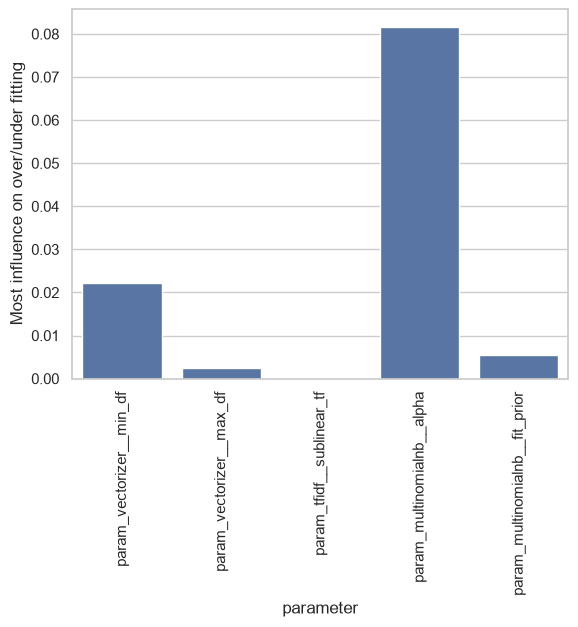

In [21]:
influence = []
for par in parameters:
    grouped = data.groupby(par)["gap"].mean()
    difference = grouped.max() - grouped.min()
    influence.append((par, difference))

influence_df = pd.DataFrame(
    influence,
    columns=["parameter", "difference"]
)

sns.barplot(
    data=influence_df,
    x="parameter",
    y="difference"
)

plt.xticks(rotation=90)
plt.ylabel("Most influence on over/under fitting")
plt.show()

Now for the independance, we are going to print all the pairs of features in a pivot table. So we can see for each value of some par1 what value of par2, gives the highest accuracy. There are 10 pairs, but we need to check each direction, so we print 20 tables.

In [22]:
for i in range(len(parameters)):
    for j in range(i + 1, len(parameters)):

        param1 = parameters[i]
        param2 = parameters[j]

        table = data.pivot_table(
            values="mean_test_score",
            index=param1,
            columns=param2,
            aggfunc="mean"
        )

    

        print("Best", param1, "for ", param2)
        print(" ")
        print(table.idxmax())
        print(" ")
        print("Best", param2, "for ", param1)
        print(" ")
        print(table.idxmax(axis=1))
        print("---------------------------------")


Best param_vectorizer__min_df for  param_vectorizer__max_df
 
param_vectorizer__max_df
0.3    0.001
0.5    0.001
0.8    0.001
dtype: float64
 
Best param_vectorizer__max_df for  param_vectorizer__min_df
 
param_vectorizer__min_df
0.001    0.3
0.005    0.3
0.010    0.3
dtype: float64
---------------------------------
Best param_vectorizer__min_df for  param_tfidf__sublinear_tf
 
param_tfidf__sublinear_tf
False    0.001
True     0.001
dtype: float64
 
Best param_tfidf__sublinear_tf for  param_vectorizer__min_df
 
param_vectorizer__min_df
0.001    True
0.005    True
0.010    True
dtype: bool
---------------------------------
Best param_vectorizer__min_df for  param_multinomialnb__alpha
 
param_multinomialnb__alpha
0.1     0.001
1.0     0.001
10.0    0.001
dtype: float64
 
Best param_multinomialnb__alpha for  param_vectorizer__min_df
 
param_vectorizer__min_df
0.001    0.1
0.005    0.1
0.010    1.0
dtype: float64
---------------------------------
Best param_vectorizer__min_df for  param_mu

We can see that these are dependant because their best values change:

min_df and alpha
max_df and sublinearr_tf 
max_df and alpha
sublinear_td and alpha
alpha and fit_prior

The rest of pairs are independant, because their values don't change in each direction. 

**5e**

I tried a lot of different models and classifiers, and a model with TfidfVectorizer and LinearSVC was the best one i found. 

Last model: 71.8% Validation
TfidfVectorizer and LinearSVC = 75.2%

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svc_pipeline = Pipeline([("tfidf", TfidfVectorizer()),("svc", LinearSVC())])

results = cross_validate(svc_pipeline, X_train, y_train, 
                         cv=5, scoring="accuracy", return_train_score=True)

print("Training accuracy:", results["train_score"].mean())
print("Validation accuracy:", results["test_score"].mean())

Training accuracy: 0.9723733184394476
Validation accuracy: 0.752454064777791


I also tried others, but they didn't give me higher accuracy:

Vectorizer(min_df=0.001, max_df=0.5) & Tfidf &: 11.2% Validation
Vectorizer & DecisionTree: 42.4%
